In [16]:
import kagglehub

path = kagglehub.dataset_download("nitaisatapathy/welfake-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/salvo/.cache/kagglehub/datasets/nitaisatapathy/welfake-dataset/versions/1


In [17]:
import pandas as pd
from torch.utils.data import DataLoader

df=pd.read_csv(path+"/WELFake_Dataset.csv")
df.describe()
df.shape


(72134, 4)

In [18]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

class FakeNewsBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.encodings['input_ids'][idx],
            self.encodings['attention_mask'][idx],
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

In [19]:
texts = df['text'].fillna('').tolist()
labels = df['label'].tolist()
titles = df['title'].fillna('').tolist()

texts_combined = [str(t) + " . " + str(c) for t, c in zip(titles, texts)]

print(f"Total samples: {len(texts_combined)}")


Total samples: 72134


In [20]:
def make_dataset(idx: list[int], tokenizer, max_len: int = 64):
    subset_texts  = [texts_combined[i] for i in idx]
    subset_labels = [labels[i] for i in idx]
    return FakeNewsBERTDataset(subset_texts, subset_labels, tokenizer, max_len)

In [21]:
import numpy as np

total_count = len(texts_combined)
train_count = int(0.7 * total_count)
val_count = int(0.1 * total_count)
test_count = total_count - train_count - val_count

rng = np.random.default_rng(42)
indices = rng.permutation(total_count)
train_idx = indices[:train_count]
val_idx   = indices[train_count:train_count + val_count]
test_idx  = indices[train_count + val_count:]

In [22]:
MAX_SEQ_LEN = 64
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_subset = make_dataset(train_idx, tokenizer, MAX_SEQ_LEN)
val_subset   = make_dataset(val_idx,   tokenizer, MAX_SEQ_LEN)
test_subset  = make_dataset(test_idx,  tokenizer, MAX_SEQ_LEN)

print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_subset)}")
print(f"Max sequence length: {MAX_SEQ_LEN}")

Train: 50493 | Val: 7213 | Test: 14428
Max sequence length: 64


In [23]:
train_set = DataLoader(train_subset, shuffle=True,  batch_size=32)
val_set   = DataLoader(val_subset,   shuffle=False, batch_size=32)
test_set  = DataLoader(test_subset,  shuffle=False, batch_size=32)

In [24]:
def get_device(verbose=True):
    """
    Select the best available device in the order:
    CUDA -> MPS -> CPU
    """

    if torch.cuda.is_available():
        device = torch.device("cuda")
        device_name = torch.cuda.get_device_name(0)

    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device("mps")
        device_name = "Apple Metal (MPS)"

    else:
        device = torch.device("cpu")
        device_name = "CPU"

    if verbose:
        print(f"Using device: {device}")
        print(f"Device name: {device_name}")

        if device.type == "cuda":
            print(f"CUDA capability: {torch.cuda.get_device_capability(0)}")
            print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    return device


DEVICE = get_device()

Using device: cuda
Device name: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA capability: (8, 9)
GPU memory: 6.06 GB


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SelfAttentionModule(nn.Module):
    """
        Self-Attention Module for sequence/point-cloud data using 1D convolutions.

        This module implements a self-attention mechanism that captures long-range
        dependencies across the input sequence. It projects the input into query,
        key, and value spaces using 1D convolutions, computes scaled dot-product
        attention, and blends the attended output with the original input via a
        learnable residual scale parameter (gamma).
    """
    def __init__(self, in_dim):
        super(SelfAttentionModule, self).__init__()

        self.query_conv = nn.Conv1d(in_dim, in_dim // 8, 1)
        self.key_conv = nn.Conv1d(in_dim, in_dim // 8, 1)
        self.value_conv = nn.Conv1d(in_dim, in_dim, 1)

        self.gamma = nn.Parameter(torch.full((1,), 0.1))
        self.scale = (in_dim // 8) ** -0.5
    def forward(self, x, return_attention=False):
        B, C, N = x.size()
        self.attn_drop = nn.Dropout(p=0.1)
        query = self.query_conv(x).view(B, -1, N).permute(0,2,1)
        key = self.key_conv(x).view(B, -1, N)

        energy = torch.bmm(query, key) * self.scale
        attention = self.attn_drop(F.softmax(energy, dim=-1))

        value = self.value_conv(x).view(B, -1, N)

        out = torch.bmm(value, attention.permute(0,2,1))
        out = self.gamma * out + x

        if return_attention:
            return out, attention

        return out

In [26]:
def squash(inputs, axis=-1):
    """
    The non-linear activation used in CapsNets.
    """
    norm = torch.norm(inputs, p=2, dim=axis, keepdim=True)
    scale = norm**2 / (1 + norm**2) / (norm + 1e-8)
    return scale * inputs


class CapsuleLayer(nn.Module):
    def __init__(self, num_capsules, num_route_nodes, in_channels, out_channels, num_iterations=3):
        super(CapsuleLayer, self).__init__()
        self.num_iterations = num_iterations
        self.num_capsules = num_capsules
        self.num_route_nodes = num_route_nodes
        self.W = nn.Parameter(torch.randn(num_capsules, num_route_nodes, in_channels, out_channels))

    def forward(self, x):
        #[Batch, num_route_nodes, in_channels]
        x = x[:, None, :, :, None]
        W = self.W[None, :, :, :, :]
        u_hat = torch.matmul(W.transpose(-1, -2), x).squeeze(-1)
        b_ij = torch.zeros(x.shape[0], self.num_capsules, x.shape[2], device=x.device)

        for i in range(self.num_iterations):
            c_ij = F.softmax(b_ij, dim=1)
            #Find the best high level capsulxe
            s_j = (c_ij[:, :, :, None] * u_hat).sum(dim=2, keepdim=True)
            v_j = squash(s_j, axis=-1)

            if i < self.num_iterations - 1:
                agreement = (u_hat * v_j).sum(dim=-1)
                b_ij = b_ij + agreement

        return v_j.squeeze(2)

In [27]:
from transformers import AutoModel


class FakeNewsCapsNet(nn.Module):
    """
    BERT-backed Capsule Network for fake news detection.
    Architecture:
        1. Frozen BERT encoder  → real per-token embeddings [B, seq, 768]
        2. Linear projection    → [B, seq, 128] + LayerNorm + Dropout
        3. Self-attention       → genuine seq×seq attention map
        4. Dynamic routing      → class capsules; L2 norm = class probability
    """

    def __init__(
        self,
        num_classes,
        bert_model_name="distilbert-base-uncased",
        max_seq_len=64,
        token_dim=128,
        dropout=0.3,
    ):
        super().__init__()
        self.max_seq_len = max_seq_len

        # Frozen BERT — no gradients, keeps memory low
        self.bert = AutoModel.from_pretrained(bert_model_name)
        for param in self.bert.parameters():
            param.requires_grad = False

        bert_hidden = self.bert.config.hidden_size  # 768 for base, 384 for distil

        self.proj = nn.Sequential(
            nn.Linear(bert_hidden, token_dim),
            nn.LayerNorm(token_dim),
            nn.Dropout(dropout),
        )

        self.attention = SelfAttentionModule(token_dim)

        self.primary_caps = nn.ModuleList(
            [nn.Conv1d(token_dim, 32, kernel_size=1) for _ in range(12)]
        )

        self.routing_layer = CapsuleLayer(
            num_capsules=num_classes,
            num_route_nodes=32 * max_seq_len,
            in_channels=12,
            out_channels=16,
        )

    def forward(self, input_ids, attention_mask, return_attention=False):
        with torch.no_grad():
            bert_out = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )
        x = bert_out.last_hidden_state

        B, S, H = x.shape
        if S < self.max_seq_len:
            pad = torch.zeros(B, self.max_seq_len - S, H, device=x.device)
            x = torch.cat([x, pad], dim=1)
        else:
            x = x[:, : self.max_seq_len, :]

        x = self.proj(x)

        x = x.permute(0, 2, 1)
        x, attention = self.attention(x, return_attention=True)

        u = [caps(x) for caps in self.primary_caps]
        u = torch.stack(u, dim=-1)
        u = u.view(B, -1, 12)
        u = squash(u)

        v = self.routing_layer(u)
        probs = torch.norm(v, p=2, dim=-1)
        if return_attention:
            return probs, attention
        return probs

In [ ]:
import math
import torch.optim as optim
import time
epochs = 30
steps_per_epoch = len(train_set)
total_steps     = epochs * steps_per_epoch
warmup_steps    = 2 * steps_per_epoch  # 2-epoch warmup

lr_lambda = lambda step: (
    step / warmup_steps if step < warmup_steps
    else 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * (step - warmup_steps) / (total_steps - warmup_steps)))
)

model = FakeNewsCapsNet(
    num_classes=2,
    bert_model_name="distilbert-base-uncased",
    max_seq_len=64,
).to(DEVICE)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
class_weights = torch.tensor([2.0, 1.0]).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []}
best_acc = 0.0
for epoch in range(epochs):
    start = time.time()
    model.train()
    train_loss, train_correct = 0, 0
    for input_ids, attention_mask, labels in train_set:
        input_ids     = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        labels        = labels.to(DEVICE)
        optimizer.zero_grad()
        probs = model(input_ids, attention_mask)
        loss  = criterion(probs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss    += loss.item()
        train_correct += (torch.argmax(probs, dim=1) == labels).sum().item()
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for input_ids, attention_mask, labels in val_set:
            input_ids      = input_ids.to(DEVICE)
            attention_mask = attention_mask.to(DEVICE)
            labels         = labels.to(DEVICE)
            probs      = model(input_ids, attention_mask)
            val_loss  += criterion(probs, labels).item()
            val_correct += (torch.argmax(probs, dim=1) == labels).sum().item()
    t_loss = train_loss / len(train_set)
    t_acc  = train_correct / len(train_subset)
    v_loss = val_loss / len(val_set)
    v_acc  = val_correct / len(val_subset)
    elapsed = time.time() - start
    current_lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | "
        f"Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f} | "
        f"LR: {current_lr:.2e} | Time: {elapsed:.1f}s"
    )
    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), "best_epoch_model-v2.pt")
        print(f"  ↑ saved new best ({best_acc:.4f})")

Epoch 01/30 | Loss: 0.6061  Acc: 0.6930 | Val Loss: 0.4047  Val Acc: 0.9292 | LR: 5.00e-04 | Time: 66.2s
  ↑ saved new best (0.9292)
Epoch 02/30 | Loss: 0.3813  Acc: 0.9548 | Val Loss: 0.3716  Val Acc: 0.9616 | LR: 1.00e-03 | Time: 67.1s
  ↑ saved new best (0.9616)
Epoch 03/30 | Loss: 0.3610  Acc: 0.9629 | Val Loss: 0.3556  Val Acc: 0.9692 | LR: 9.97e-04 | Time: 67.2s
  ↑ saved new best (0.9692)
Epoch 04/30 | Loss: 0.3559  Acc: 0.9653 | Val Loss: 0.3528  Val Acc: 0.9574 | LR: 9.89e-04 | Time: 68.5s
Epoch 05/30 | Loss: 0.3527  Acc: 0.9660 | Val Loss: 0.3526  Val Acc: 0.9696 | LR: 9.75e-04 | Time: 71.4s
  ↑ saved new best (0.9696)
Epoch 06/30 | Loss: 0.3505  Acc: 0.9679 | Val Loss: 0.3539  Val Acc: 0.9549 | LR: 9.55e-04 | Time: 72.9s
Epoch 07/30 | Loss: 0.3492  Acc: 0.9677 | Val Loss: 0.3453  Val Acc: 0.9735 | LR: 9.31e-04 | Time: 74.1s
  ↑ saved new best (0.9735)
Epoch 08/30 | Loss: 0.3474  Acc: 0.9693 | Val Loss: 0.3454  Val Acc: 0.9656 | LR: 9.02e-04 | Time: 75.2s
Epoch 09/30 | Loss: 

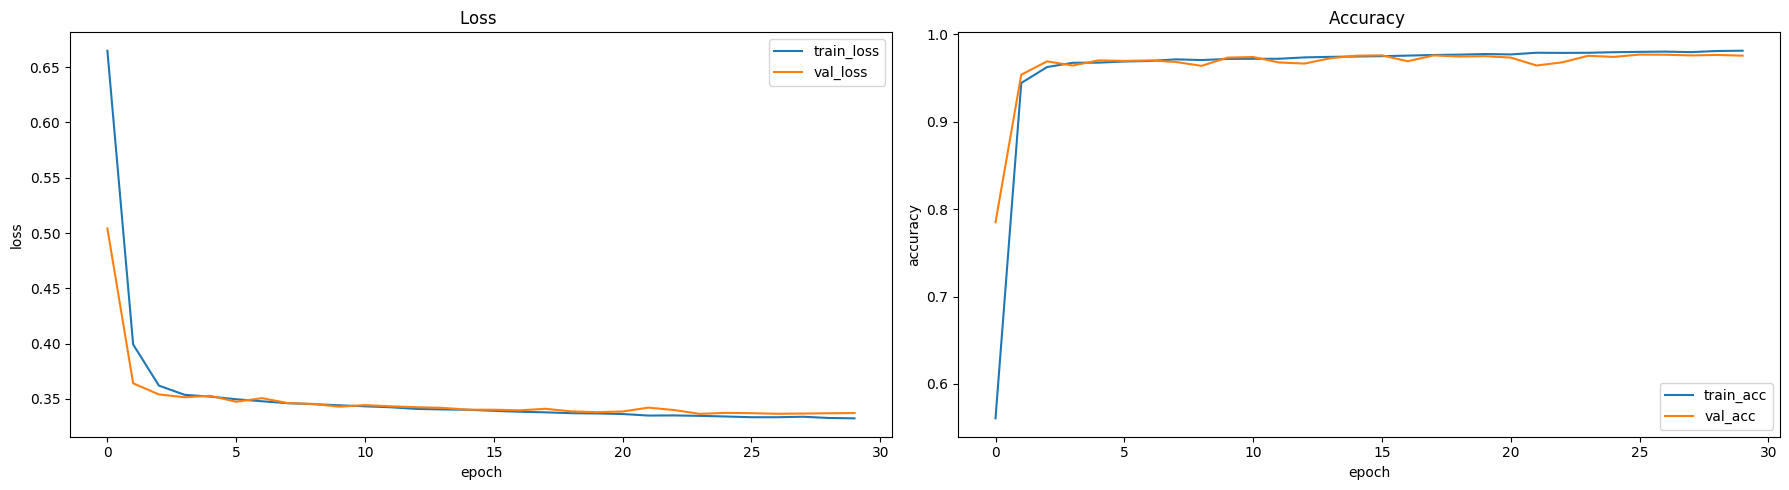

In [ ]:
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- Plot 1: Loss ---
axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_title("Loss ")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

# --- Plot 2: Accuracy ---
axes[1].plot(history["train_acc"], label="train_acc")
axes[1].plot(history["val_acc"], label="val_acc")
axes[1].set_title("Accuracy ")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()




plt.tight_layout()

# 3. Save the single grid image
plt.savefig("metrics_grid_na.png", dpi=150)
plt.show()


In [14]:
model = FakeNewsCapsNet(num_classes=2, bert_model_name="distilbert-base-uncased")
model.load_state_dict(torch.load("best_epoch_model-4.pt", map_location=DEVICE))
model.to(DEVICE)
model.eval()

test_loss = 0
test_correct = 0
criterion = nn.CrossEntropyLoss()
all_preds = []
all_labels = []
threshold = 0.5

with torch.no_grad():
    for input_ids, attention_mask, batch_labels in test_set:
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        probs = model(input_ids, attention_mask)
        loss = criterion(probs, batch_labels)
        test_loss += loss.item()

        probs_softmax = torch.softmax(probs, dim=1)
        prob_positive = probs_softmax[:, 1]
        predictions = (prob_positive >= threshold).long()

        test_correct += (predictions == batch_labels).sum().item()
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

final_test_loss = test_loss / len(test_set)
final_test_acc = test_correct / len(test_subset)
print(f"--- TEST SET RESULTS ---")
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f} ({test_correct}/{len(test_subset)})")

--- TEST SET RESULTS ---
Final Test Loss: 0.3454
Final Test Accuracy: 0.9787 (14120/14428)


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        Real       0.98      0.98      0.98      7064
        Fake       0.98      0.98      0.98      7364

    accuracy                           0.98     14428
   macro avg       0.98      0.98      0.98     14428
weighted avg       0.98      0.98      0.98     14428



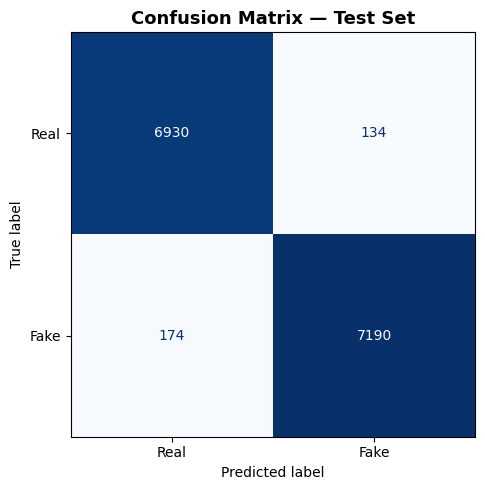

Saved → confusion_matrix.png


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

class_names = ["Real", "Fake"]

# Classification report
print("--- CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved → confusion_matrix.png")


In [12]:
labels = df['label'].tolist()

In [13]:
import re
import string
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words("english"))

In [14]:
def _is_meaningful_token(token: str) -> bool:
    token = token.replace("##", "")
    token = token.strip(string.punctuation)

    if len(token) < 3:
        return False
    if token.lower() in STOPWORDS:
        return False
    if not re.match(r"^[a-zA-Z]+$", token):
        return False

    return True


def _merge_subwords(tokens, indices):
    """
    Merge BERT subwords into full words and keep correct index mapping.

    Returns:
        merged_tokens: list[str]
        merged_indices: list[list[int]]  (original token indices per merged token)
    """
    merged_tokens = []
    merged_indices = []

    current_token = ""
    current_indices = []

    for t, idx in zip(tokens, indices):
        if t.startswith("##"):
            current_token += t[2:]
            current_indices.append(idx)
        else:
            if current_token:
                merged_tokens.append(current_token)
                merged_indices.append(current_indices)

            current_token = t
            current_indices = [idx]

    if current_token:
        merged_tokens.append(current_token)
        merged_indices.append(current_indices)

    return merged_tokens, merged_indices

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from typing import Optional
import torch.nn as nn
class _Hook:
    def __init__(self):
        self.value = None
        self._handle = None

    def register(self, module: nn.Module) -> None:
        """Attach a forward hook to *module*; captured output stored in self.value."""
        def _hook_fn(module, input, output):
            self.value = output.detach()

        self._handle = module.register_forward_hook(_hook_fn)

    def remove(self) -> None:
        """Remove the hook from the module."""
        if self._handle is not None:
            self._handle.remove()
            self._handle = None

In [16]:
class InstrumentedCapsuleLayer(nn.Module):
    """
    Drop-in replacement for CapsuleLayer that stores the final
    coupling coefficients after dynamic routing.

    layer.last_c after a forward pass has shape [B, num_route_nodes, num_capsules].
    """
    def __init__(self, original_layer):
        super().__init__()
        self._orig = original_layer
        self.last_c: Optional[torch.Tensor] = None

    def forward(self, x):
        B = x.shape[0]
        n_caps   = self._orig.num_capsules
        n_routes = self._orig.num_route_nodes

        x_exp = x[:, None, :, :, None]
        W_exp = self._orig.W[None, :, :, :, :]
        u_hat = torch.matmul(W_exp.transpose(-1, -2), x_exp).squeeze(-1)

        b_ij = torch.zeros(B, n_caps, n_routes, device=x.device)
        for i in range(self._orig.num_iterations):
            c_ij = torch.softmax(b_ij, dim=1)
            s_j  = (c_ij[:, :, :, None] * u_hat).sum(dim=2, keepdim=True)
            v_j  = self._squash(s_j)
            if i < self._orig.num_iterations - 1:
                agreement = (u_hat * v_j).sum(dim=-1)
                b_ij = b_ij + agreement

        # [B, n_caps, n_routes] → [B, n_routes, n_caps]
        self.last_c = c_ij.detach().cpu().permute(0, 2, 1)
        return v_j.squeeze(2)

    @staticmethod
    def _squash(x):
        n2 = (x ** 2).sum(dim=-1, keepdim=True)
        return (n2 / (1 + n2)) * (x / (n2.sqrt() + 1e-8))

In [17]:
class InstrumentedCapsuleLayer(nn.Module):
    """
    Drop-in replacement for CapsuleLayer that stores the final
    coupling coefficients after dynamic routing.

    layer.last_c after a forward pass has shape [B, num_route_nodes, num_capsules].
    """
    def __init__(self, original_layer):
        super().__init__()
        self._orig = original_layer
        self.last_c: Optional[torch.Tensor] = None

    def forward(self, x):
        B = x.shape[0]
        n_caps   = self._orig.num_capsules
        n_routes = self._orig.num_route_nodes

        x_exp = x[:, None, :, :, None]
        W_exp = self._orig.W[None, :, :, :, :]
        u_hat = torch.matmul(W_exp.transpose(-1, -2), x_exp).squeeze(-1)

        b_ij = torch.zeros(B, n_caps, n_routes, device=x.device)
        for i in range(self._orig.num_iterations):
            c_ij = torch.softmax(b_ij, dim=1)
            s_j  = (c_ij[:, :, :, None] * u_hat).sum(dim=2, keepdim=True)
            v_j  = self._squash(s_j)
            if i < self._orig.num_iterations - 1:
                agreement = (u_hat * v_j).sum(dim=-1)
                b_ij = b_ij + agreement

        # [B, n_caps, n_routes] → [B, n_routes, n_caps]
        self.last_c = c_ij.detach().cpu().permute(0, 2, 1)
        return v_j.squeeze(2)

    @staticmethod
    def _squash(x):
        n2 = (x ** 2).sum(dim=-1, keepdim=True)
        return (n2 / (1 + n2)) * (x / (n2.sqrt() + 1e-8))

In [ ]:
class CapsNetExplainer:
    """
    Wraps a trained FakeNewsCapsNet and produces an interpretability
    dashboard as a Plotly HTML file.

    Parameters
    ----------
    model       : FakeNewsCapsNet instance (eval mode)
    tokenizer   : HuggingFace tokenizer matching the BERT backbone
    class_names : list of class label strings, e.g. ["Real", "Fake"]
    device      : torch device string
    """

    COLORS = {
        "fake": "#E8593C",
        "real": "#3B8BD4",
        "neutral": "#B4B2A9",
        "purple": "#7F77DD",
        "teal": "#1D9E75",
        "amber": "#EF9F27",
    }

    def __init__(self, model, tokenizer, class_names=("Real", "Fake"), device="cpu"):
        self.model = model.eval().to(device)
        self.tokenizer = tokenizer
        self.class_names = list(class_names)
        self.device = device

        if not isinstance(model.routing_layer, InstrumentedCapsuleLayer):
            model.routing_layer = InstrumentedCapsuleLayer(model.routing_layer)

        self._linear_hook = _Hook()
        self._linear_hook.register(model.proj[0])

        self._prim_hooks = []
        for cap in model.primary_caps:
            h = _Hook()
            target = cap[0] if isinstance(cap, nn.Sequential) else cap
            h.register(target)
            self._prim_hooks.append(h)

    def explain(
        self, text: str, save_html: str = "capsnet_report.html", show: bool = True
    ) -> dict:
        artifacts = self._run_inference(text)
        fig = self._build_dashboard(text, artifacts)
        pio.write_html(fig, save_html, auto_open=show)
        print(f"[CapsNetExplainer] Dashboard saved → {save_html}")
        return artifacts

    def explain_batch(
        self, texts: list, save_html: str = "capsnet_batch.html", show: bool = True
    ):
        for i, t in enumerate(texts):
            out = save_html.replace(".html", f"_{i}.html")
            self.explain(t, save_html=out, show=show)

    def _run_inference(self, text: str) -> dict:
        enc = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=self.model.max_seq_len,
            padding="max_length",
        )
        input_ids = enc["input_ids"].to(self.device)
        attn_mask = enc["attention_mask"].to(self.device)

        with torch.no_grad():
            probs, attn = self.model(input_ids, attn_mask, return_attention=True)

        # ── STEP 1: remove special tokens ───────────────────────────
        ids = input_ids[0].cpu().numpy()
        tokens = self.tokenizer.convert_ids_to_tokens(ids)
        filtered_tokens, filtered_indices = [], []
        for i, t in enumerate(tokens):
            if t in ("[PAD]", "[CLS]", "[SEP]", "<pad>"):
                continue
            filtered_tokens.append(t)
            filtered_indices.append(i)

        # ── STEP 2: merge subwords into full words ──────────────────
        merged_tokens, merged_indices = _merge_subwords(
            filtered_tokens, filtered_indices
        )

        # ── STEP 3: keep only meaningful tokens ─────────────────────
        valid_tokens, valid_idx_groups = [], []
        for tok, idx_group in zip(merged_tokens, merged_indices):
            clean_tok = tok.strip(string.punctuation)
            if not _is_meaningful_token(clean_tok):
                continue
            valid_tokens.append(clean_tok)
            valid_idx_groups.append(idx_group)

        attn_np = attn[0].cpu().numpy()  # [seq, seq]
        n_words = len(valid_idx_groups)
        attn_sub = np.zeros((n_words, n_words))
        for i, group_i in enumerate(valid_idx_groups):
            for j, group_j in enumerate(valid_idx_groups):
                vals = [attn_np[ii, jj] for ii in group_i for jj in group_j]
                attn_sub[i, j] = np.mean(vals) if vals else 0.0

        n_valid = attn_sub.shape[1]

        row_entropy = -(attn_sub * np.log(attn_sub + 1e-9)).sum(axis=1)
        sharp_mask = row_entropy <= np.percentile(row_entropy, 50)
        sharp = attn_sub[sharp_mask] if sharp_mask.any() else attn_sub
        raw = sharp.mean(axis=0)
        raw -= raw.min()
        token_attn = raw / (raw.max() + 1e-8)

        attn_log = np.log1p(attn_sub * n_valid)
        attn_display = attn_log / (attn_log.max() + 1e-8)

        lin_acts = self._linear_hook.value
        if lin_acts is not None:
            proj_importance = lin_acts[0].abs().mean(dim=-1).numpy()
            proj_sub = np.array(
                [proj_importance[group].mean() for group in valid_idx_groups]
            )
            proj_sub /= proj_sub.max() + 1e-8
        else:
            proj_sub = np.ones(len(valid_idx_groups))

        routing_c = self.model.routing_layer.last_c
        max_seq = self.model.max_seq_len
        n_cls = len(self.class_names)
        if routing_c is not None:
            r = routing_c[0].reshape(-1, max_seq, n_cls)  # [32, seq, n_cls]
            r_per_tok = r.mean(dim=0).numpy()  # [seq, n_cls]
            routing_per_token = np.array(
                [r_per_tok[group].mean(axis=0) for group in valid_idx_groups]
            )
            routing_mean = routing_c[0].mean(dim=0).numpy()
        else:
            routing_per_token = np.full((len(valid_idx_groups), n_cls), 1.0 / n_cls)
            routing_mean = np.ones(n_cls) / n_cls

        probs_np = probs[0].cpu().numpy()
        pred_cls = int(probs_np.argmax())

        return dict(
            text=text,
            tokens=list(valid_tokens),
            token_attn=token_attn,
            attn_matrix=attn_sub,
            attn_display=attn_display,
            proj_importance=proj_sub,
            routing_mean=routing_mean,
            routing_per_token=routing_per_token,
            probs=probs_np,
            pred_cls=pred_cls,
        )


    def _build_dashboard(self, text: str, art: dict) -> go.Figure:
        tokens = art["tokens"]
        n = len(tokens)
        is_fake = art["pred_cls"] == 1
        verdict = self.class_names[art["pred_cls"]]
        verdict_color = self.COLORS["fake"] if is_fake else self.COLORS["real"]

        fig = make_subplots(
            rows=4,
            cols=2,
            subplot_titles=(
                "Token Self-Attention (above-average attention only)",
                "Attention Matrix — log-normalised",
                "Class Capsule Norms",
                "Per-Token Routing Bias (Fake − Real)", 
                "BERT Projection Importance (pre-LayerNorm, top tokens)",
                "",
                "",
                "",
            ),
            specs=[
                [{"type": "bar"}, {"type": "heatmap"}],
                [{"type": "bar", "colspan": 2},    None],
                [{"type": "bar", "colspan": 2},    None],
                [{"type": "bar", "colspan": 2},    None],
            ],
            vertical_spacing=0.12,
            horizontal_spacing=0.12,
        )

        # ── 1. Token attention ─────────────────────────────────
        colors_tok = [
            (
                self.COLORS["fake"]
                if (is_fake and v > 0.5)
                else (
                    self.COLORS["real"]
                    if (not is_fake and v > 0.5)
                    else self.COLORS["neutral"]
                )
            )
            for v in art["token_attn"]
        ]
        fig.add_trace(
            go.Bar(
                x=tokens,
                y=art["token_attn"].tolist(),
                marker_color=colors_tok,
                hovertemplate="<b>%{x}</b><br>above-avg attention: %{y:.3f}<extra></extra>",
                name="Token attention",
            ),
            row=1,
            col=1,
        )
        fig.update_yaxes(range=[0, 1.05], title_text="Normalised weight", row=1, col=1)

        # ── 2. Attention matrix (log-normalised) ───────────────
        cscale = (
            [[0, "#FFF5F5"], [0.5, "#F0997B"], [1, "#E8593C"]]
            if is_fake
            else [[0, "#EBF5FF"], [0.5, "#85B7EB"], [1, "#185FA5"]]
        )
        fig.add_trace(
            go.Heatmap(
                z=art["attn_display"].tolist(),
                x=tokens,
                y=tokens,
                colorscale=cscale,
                showscale=True,
                colorbar=dict(
                    len=0.35,
                    y=0.78,
                    x=1.01,
                    thickness=10,
                    title=dict(text="log-norm", side="right"),
                ),
                hovertemplate="query: <b>%{y}</b><br>key: <b>%{x}</b><br>log-norm: %{z:.3f}<extra></extra>",
                name="Attention",
            ),
            row=1,
            col=2,
        )

        # ── 4. Class capsule norms ─────────────────────────────
        fig.add_trace(
            go.Bar(
                x=self.class_names,
                y=art["probs"].tolist(),
                marker_color=[self.COLORS["real"], self.COLORS["fake"]],
                marker_opacity=0.8,
                hovertemplate="%{x}: %{y:.3f}<extra></extra>",
                name="Class norms",
                text=[f"{v:.2f}" for v in art["probs"].tolist()],
                textposition="outside",
            ),
            row=2,
            col=1,
        )
        fig.update_yaxes(range=[0, 1.15], title_text="Capsule L2 norm", row=2, col=2)

        # ── 5. Per-token routing bias ──────────────────────────
        routing_bias = (
            art["routing_per_token"][:, 1] - art["routing_per_token"][:, 0]
        ).tolist()
        bias_colors = [
            self.COLORS["fake"] if b > 0 else self.COLORS["real"] for b in routing_bias
        ]
        fig.add_trace(
            go.Bar(
                x=tokens,
                y=routing_bias,
                marker_color=bias_colors,
                marker_opacity=0.8,
                hovertemplate="<b>%{x}</b><br>routing bias (Fake−Real): %{y:.4f}<extra></extra>",
                name="Routing bias",
            ),
            row=3,
            col=1,
        )
        fig.update_yaxes(title_text="Routing bias (Fake − Real)", row=3, col=1)
        fig.update_xaxes(tickangle=-40, row=3, col=1)
        fig.add_hline(
            y=0, line_width=1, line_dash="dot", line_color="#999", row=3, col=1
        )

        # ── 6. BERT projection importance ─────────────────────
        order = np.argsort(art["proj_importance"])[::-1]
        top_n = min(n, 15)
        top_idx = order[:top_n]
        top_tok = [tokens[i] for i in top_idx]
        top_imp = art["proj_importance"][top_idx].tolist()
        imp_cols = [
            (
                self.COLORS["fake"]
                if (is_fake and v > 0.5)
                else (
                    self.COLORS["real"]
                    if (not is_fake and v > 0.5)
                    else self.COLORS["neutral"]
                )
            )
            for v in top_imp
        ]
        fig.add_trace(
            go.Bar(
                x=top_tok,
                y=top_imp,
                marker_color=imp_cols,
                marker_opacity=0.75,
                hovertemplate="<b>%{x}</b><br>mean |activation|: %{y:.3f}<extra></extra>",
                name="Projection importance",
            ),
            row=4,
            col=1,
        )
        fig.update_yaxes(
            range=[0, 1.1], title_text="Normalised importance", row=4, col=1
        )

        # ── layout & title ─────────────────────────────────────
        pred_pct = art["probs"][art["pred_cls"]] * 100

        fig.update_layout(
            title=dict(
                text=(
                    f"<b>FakeNewsCapsNet — Interpretability Report</b><br>"
                    f"<span style='font-size:13px;color:{verdict_color}'>"
                    f"Verdict: <b>{verdict}</b> ({pred_pct:.1f}% confidence)</span>"
                ),
                x=0.02,
                xanchor="left",
                font=dict(size=16),
            ),
            height=1400,
            width=1200,
            showlegend=False,
            template="plotly_white",
            paper_bgcolor="#FAFAF8",
            plot_bgcolor="#FFFFFF",
            font=dict(family="Arial, sans-serif", size=11, color="#3d3d3a"),
            margin=dict(t=140, b=40, l=60, r=80),
        )

        for row in range(1, 5):
            for col in range(1, 3):
                fig.update_xaxes(showgrid=False, row=row, col=col)
                fig.update_yaxes(
                    showgrid=True, gridcolor="#EBEBEB", gridwidth=0.5, row=row, col=col
                )

        fig.add_annotation(
            x=0.5,
            y=1.07,
            xref="paper",
            yref="paper",
            text=f"  ● PREDICTED: <b>{verdict}</b> ({pred_pct:.1f}% confidence)  ",
            showarrow=False,
            align="center",
            font=dict(size=13, color="white"),
            bgcolor=verdict_color,
            bordercolor=verdict_color,
            borderwidth=1,
            borderpad=6,
            opacity=0.9,
        )

        return fig

In [ ]:
print("Building mock model for demo …")
model = FakeNewsCapsNet(num_classes=2, bert_model_name="distilbert-base-uncased")
model.load_state_dict(torch.load("best_epoch_model-v2-2.pt", map_location="cpu"))
model.eval()
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

explainer = CapsNetExplainer(model, tokenizer, class_names=["Real", "Fake"])

text = """"Mayor Accidentally Declares City a Sovereign Nation While Signing Wrong Document"
City Hall scrambled Friday after Mayor Gerald Pflum signed what he believed was a parking reform ordinance, but was in fact a declaration of independence drafted by a local history club as a joke. The State Department has not yet responded."""
explainer.explain(texts_combined[6])


Building mock model for demo …


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[CapsNetExplainer] Dashboard saved → capsnet_report.html


## Word Influence Statistics: Fake vs Real News

Aggregate per-word importance scores (attention, projection, routing bias) across many correctly-classified samples to find which words most strongly characterise each class.

In [ ]:
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


N_SAMPLES = 600

fake_test_idx = [i for i in test_idx if labels[i] == 1]
real_test_idx = [i for i in test_idx if labels[i] == 0]

rng_stats = np.random.default_rng(0)
fake_sample = rng_stats.choice(
    fake_test_idx, size=min(N_SAMPLES, len(fake_test_idx)), replace=False
)
real_sample = rng_stats.choice(
    real_test_idx, size=min(N_SAMPLES, len(real_test_idx)), replace=False
)

word_attn = {0: defaultdict(list), 1: defaultdict(list)}
word_proj = {0: defaultdict(list), 1: defaultdict(list)}
word_routing = {
    0: defaultdict(list),
    1: defaultdict(list),
}
word_count = {0: defaultdict(int), 1: defaultdict(int)}

print("Collecting word statistics …")
skipped = 0
for cls_id, sample_indices in [(0, real_sample), (1, fake_sample)]:
    for idx in sample_indices:
        try:
            art = explainer._run_inference(texts_combined[idx])
        except Exception:
            skipped += 1
            continue

        if art["pred_cls"] != cls_id:
            skipped += 1
            continue

        for tok, attn, proj, rout in zip(
            art["tokens"],
            art["token_attn"],
            art["proj_importance"],
            art["routing_per_token"][:, cls_id],
        ):
            w = tok.lower()
            word_attn[cls_id][w].append(float(attn))
            word_proj[cls_id][w].append(float(proj))
            word_routing[cls_id][w].append(float(rout))
            word_count[cls_id][w] += 1

print(f"Done. Skipped {skipped} samples (misclassified or error).")
print(
    f"  Real vocab size: {len(word_count[0])}  |  Fake vocab size: {len(word_count[1])}"
)

Done. Skipped 33 samples (misclassified or error).
  Real vocab size: 5142  |  Fake vocab size: 5247


In [ ]:
import pandas as pd

MIN_FREQ = 5  # word must appear at least this many times
TOP_N = 25  # top words to show per chart

COLOR_REAL = "#3B8BD4"
COLOR_FAKE = "#E8593C"


def build_ranking(cls_id, metric_dict, min_freq=MIN_FREQ):
    """
    For a class, build a DataFrame ranked by:
        combined_score = mean_score * log1p(count)
    (frequency-weighted importance)
    """
    rows = []
    for word, scores in metric_dict[cls_id].items():
        cnt = word_count[cls_id][word]
        if cnt < min_freq:
            continue
        rows.append(
            {
                "word": word,
                "count": cnt,
                "mean_score": np.mean(scores),
                "combined": np.mean(scores) * np.log1p(cnt),
            }
        )
    df = (
        pd.DataFrame(rows)
        .sort_values("combined", ascending=False)
        .reset_index(drop=True)
    )
    return df


rankings = {}
for sig_name, sig_dict in [
    ("attention", word_attn),
    ("projection", word_proj),
    ("routing", word_routing),
]:
    rankings[sig_name] = {
        0: build_ranking(0, sig_dict),
        1: build_ranking(1, sig_dict),
    }

print(f"Top {TOP_N} Real-news words by attention:")
print(
    rankings["attention"][0]
    .head(TOP_N)[["word", "count", "mean_score", "combined"]]
    .to_string(index=False)
)
print(f"\nTop {TOP_N} Fake-news words by attention:")
print(
    rankings["attention"][1]
    .head(TOP_N)[["word", "count", "mean_score", "combined"]]
    .to_string(index=False)
)

Top 25 Real-news words by attention:
      word  count  mean_score  combined
   reuters    392    0.975470  5.827270
     times    100    0.953893  4.402332
       cnn     10    0.627442  1.504540
      york    121    0.312183  1.499735
       new    192    0.262275  1.380274
washington    161    0.232572  1.183232
     daily      8    0.366776  0.805889
 editorial      6    0.403145  0.784484
      live      9    0.329846  0.759498
    online      5    0.417513  0.748083
  facebook      8    0.338725  0.744255
     world     25    0.225739  0.735479
   despite     10    0.304082  0.729157
  november      5    0.406464  0.728285
     video      6    0.366670  0.713507
   tuesday     70    0.165290  0.704579
 according     17    0.225923  0.653003
    friday     72    0.151514  0.650066
   killing      8    0.292600  0.642908
terrorists      5    0.356837  0.639366
     miami      5    0.356143  0.638123
      best      7    0.297644  0.618934
      news     35    0.171678  0.615213
   

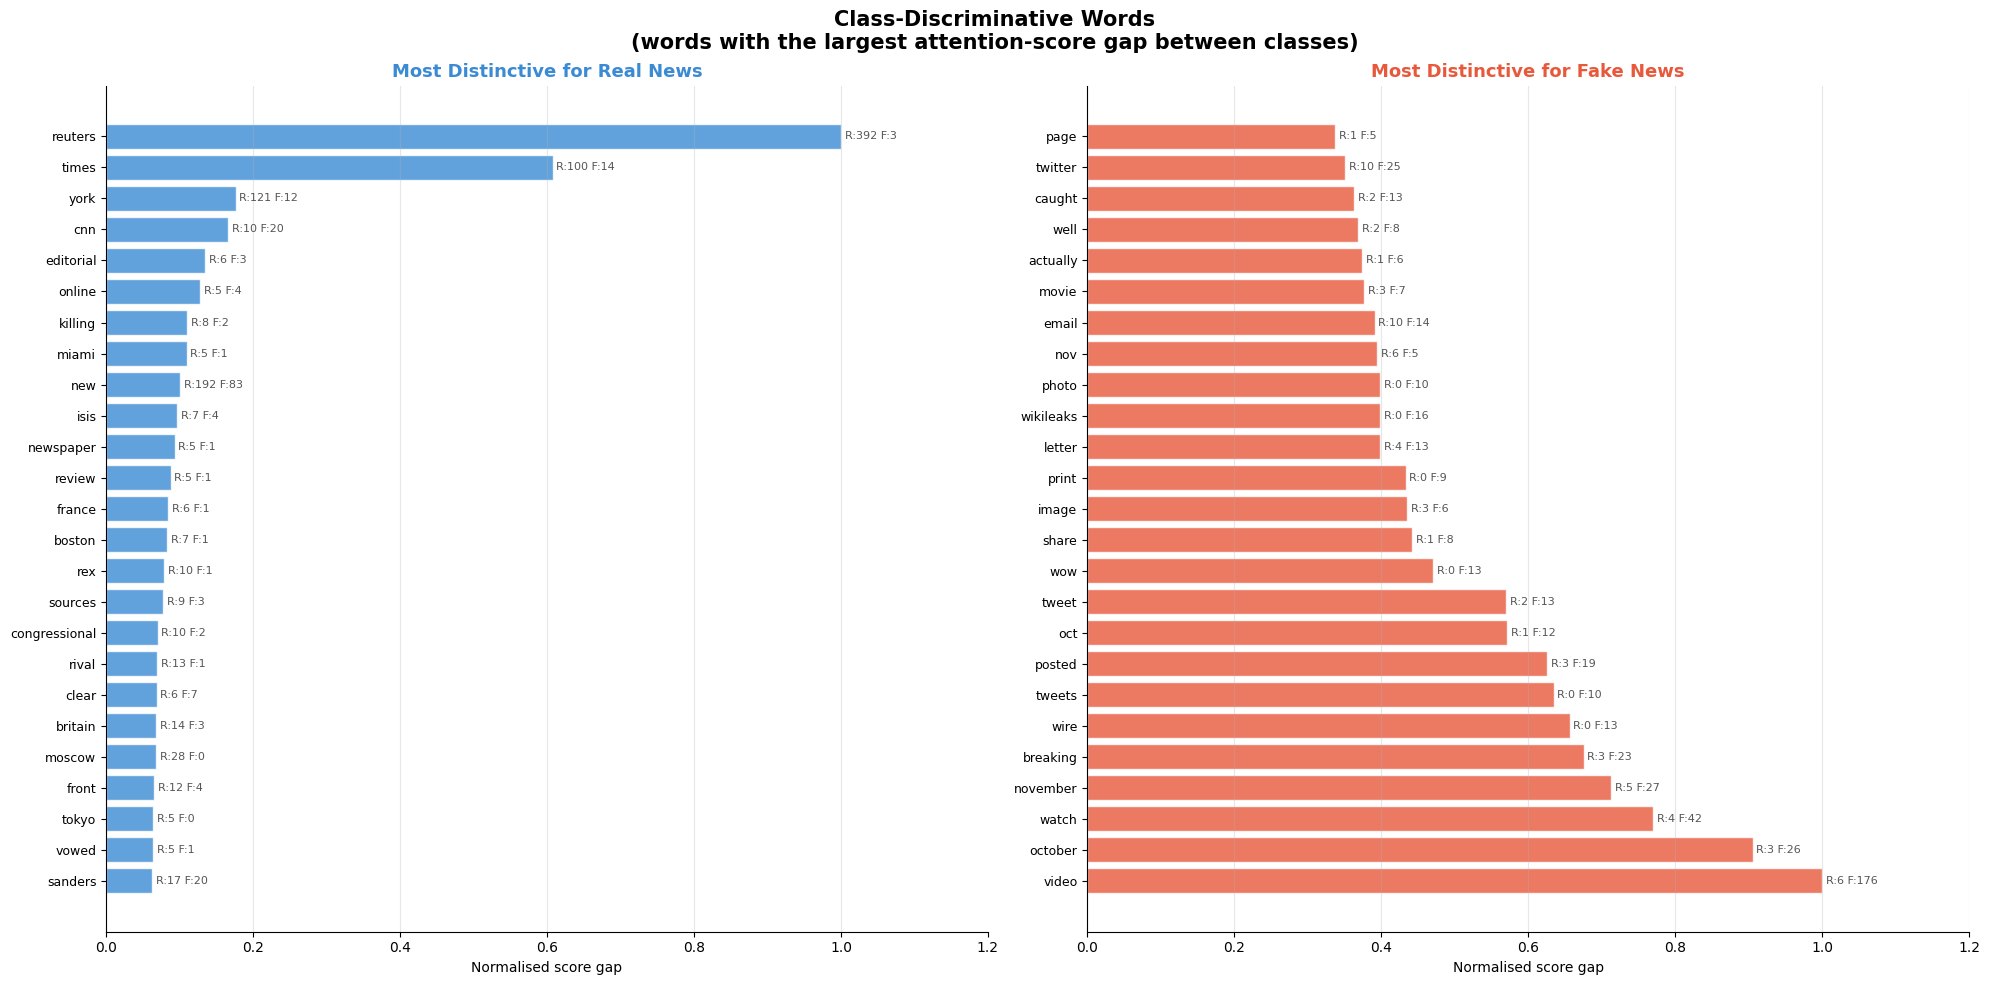

Saved → word_discriminative_stats.png


In [45]:
all_words = set(rankings["attention"][0]["word"]) | set(
    rankings["attention"][1]["word"]
)

disc_rows = []
for word in all_words:
    r_df = rankings["attention"][0]
    f_df = rankings["attention"][1]
    r_score = r_df.loc[r_df["word"] == word, "combined"].values
    f_score = f_df.loc[f_df["word"] == word, "combined"].values
    r_val = float(r_score[0]) if len(r_score) else 0.0
    f_val = float(f_score[0]) if len(f_score) else 0.0
    r_cnt = int(word_count[0].get(word, 0))
    f_cnt = int(word_count[1].get(word, 0))
    disc_rows.append(
        {
            "word": word,
            "real_score": r_val,
            "fake_score": f_val,
            "real_count": r_cnt,
            "fake_count": f_cnt,
            "diff_fake_real": f_val - r_val,
        }
    )

disc_df = pd.DataFrame(disc_rows)

top_fake_disc = disc_df.nlargest(TOP_N, "diff_fake_real")
top_real_disc = disc_df.nsmallest(TOP_N, "diff_fake_real")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle(
    "Class-Discriminative Words\n(words with the largest attention-score gap between classes)",
    fontsize=15,
    fontweight="bold",
)

for ax, df, cls_name, color in [
    (axes[0], top_real_disc.iloc[::-1], "Real", COLOR_REAL),
    (axes[1], top_fake_disc, "Fake", COLOR_FAKE),
]:
    diff_abs = df["diff_fake_real"].abs()
    norm = diff_abs / diff_abs.max()
    bars = ax.barh(df["word"], norm, color=color, alpha=0.8, edgecolor="white")
    for bar, cnt_r, cnt_f in zip(bars, df["real_count"], df["fake_count"]):
        ax.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"R:{cnt_r} F:{cnt_f}",
            va="center",
            fontsize=8,
            color="#555",
        )
    ax.set_title(
        f"Most Distinctive for {cls_name} News",
        fontsize=13,
        fontweight="bold",
        color=color,
    )
    ax.set_xlabel("Normalised score gap", fontsize=10)
    ax.set_xlim(0, 1.2)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("word_discriminative_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → word_discriminative_stats.png")